# EasyEM in a notebook

Two things about Jupyter that this notebook works around:

- `uvicorn.run()` wants to own the event loop, and the kernel already does. So
  we use FastAPI's `TestClient`, which exercises the whole application —
  middleware, dependencies, error handlers — without a socket. Same code paths,
  no server.
- The worker is a blocking loop. Running it in a cell would freeze the kernel,
  so we call its unit of work, `process_one`, by hand.

Nothing here is a simulation of the product. It *is* the product, driven from
Python instead of curl.

## 0. Setup

The cell below finds the repository root and puts it on the path, so the
notebook works whether it sits in `notebooks/`, at the root, or somewhere else
entirely. If it cannot find `easyem/`, set `REPO` by hand.

For real work, install the package once instead — that also pulls in the
dependencies:

```bash
cd easyem-saas
pip install -e ".[dev]"
```

In [1]:
import pathlib
import sys

# Walk up from the working directory looking for the package.
REPO = None
for candidate in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents][:4]:
    if (candidate / "easyem" / "notebook.py").exists():
        REPO = candidate
        break

if REPO is None:
    raise SystemExit(
        "Could not find the easyem package. Set REPO to the directory that "
        "contains easyem/, e.g. REPO = pathlib.Path('/path/to/easyem-saas')"
    )

if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
print("repository:", REPO)

repository: /home/claude/easyem-saas


In [2]:
try:
    from easyem.notebook import bootstrap
except ModuleNotFoundError as exc:
    raise SystemExit(
        "Missing dependency: " + str(exc.name)
        + ". Install everything with:  pip install -e '" + str(REPO) + "[dev]'"
    ) from exc

nb = bootstrap("easyem-notebook.db")   # fresh=False to keep data between runs
print("database:", nb.db_path)

database: /home/claude/easyem-saas/notebooks/easyem-notebook.db


/usr/local/lib/python3.12/dist-packages/fastapi/testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


---

## 1. The Engineering Engine, on its own

Start here. No accounts, no credits, no HTTP — just the physics. This is the
part worth checking first, because everything else is plumbing around it.

In [3]:
from easyem.engineering.analytical import patch

design = patch.design(
    frequency_hz=2.45e9,
    epsilon_r=3.38,        # Rogers RO4003C
    height_m=0.813e-3,
    loss_tangent=0.0027,
)

print(f"patch        {design.width_m*1e3:.2f} x {design.length_m*1e3:.2f} mm")
print(f"eps_eff      {design.epsilon_eff:.3f}")
print(f"edge R       {design.input_resistance_edge_ohm:.0f} ohm")
print(f"inset        {design.inset_feed_offset_m*1e3:.2f} mm "
      f"-> {design.inset_resistance_ohm:.1f} ohm")
print(f"bandwidth    {design.bandwidth_fraction*100:.2f} %")
print(f"directivity  {design.directivity_dbi:.2f} dBi")
print()
for w in design.warnings:
    print("!", w)

patch        41.34 x 33.10 mm
eps_eff      3.260
edge R       283 ohm
inset        12.00 mm -> 49.6 ohm
bandwidth    0.65 %
directivity  6.35 dBi

! Estimated bandwidth is 0.65 %, which leaves almost no margin for fabrication tolerance. Consider a thicker or lower-permittivity substrate.
! Feed reactance is not modelled. The inset is snapped to a 0.05 mm design grid, so the predicted return loss is an upper bound; a fabricated part will do worse.


The warnings are not decoration. This model ignores feed reactance and snaps the
inset to a 0.05 mm design grid, so its predicted return loss is an upper bound —
a fabricated part will do worse. Stated limits are worth more than a fudge
factor that hides them.

### Check it against a textbook

The engine agrees with Balanis's worked example to about 0.1 %. If you change
the physics, this is the first thing that should still hold.

In [4]:
b = patch.design(frequency_hz=10e9, epsilon_r=2.2, height_m=0.1588e-2)
print(f"          EasyEM      Balanis 4th ed. §14.2")
print(f"width     {b.width_m*100:.4f} cm   1.186 cm")
print(f"length    {b.length_m*100:.4f} cm   0.906 cm")

# And the round trip: a patch of these dimensions must resonate where we asked.
back = patch.resonant_frequency(
    length_m=design.length_m, width_m=design.width_m,
    epsilon_r=3.38, height_m=0.813e-3,
)
print(f"\nround trip: {back/1e9:.6f} GHz (asked for 2.45)")

          EasyEM      Balanis 4th ed. §14.2
width     1.1850 cm   1.186 cm
length    0.9053 cm   0.906 cm

round trip: 2.450000 GHz (asked for 2.45)


### Sweeping a design parameter

Substrate thickness is the usual lever: thicker means wider bandwidth and worse
surface-wave behaviour. The engine makes that trade visible in a few lines.

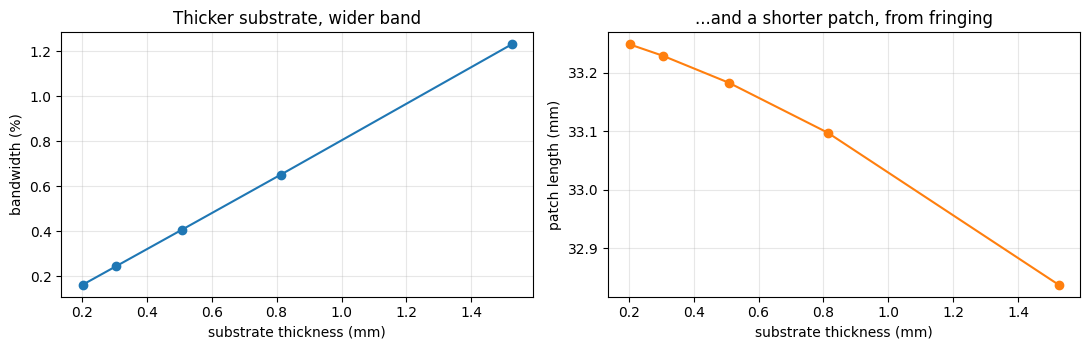

In [5]:
import matplotlib.pyplot as plt

thicknesses_mm = [0.203, 0.305, 0.508, 0.813, 1.524]
bw, gain, length = [], [], []

for h in thicknesses_mm:
    d = patch.design(frequency_hz=2.45e9, epsilon_r=3.38,
                     height_m=h*1e-3, loss_tangent=0.0027)
    bw.append(d.bandwidth_fraction * 100)
    gain.append(d.directivity_dbi)
    length.append(d.length_m * 1e3)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(thicknesses_mm, bw, "o-")
ax[0].set_xlabel("substrate thickness (mm)"); ax[0].set_ylabel("bandwidth (%)")
ax[0].set_title("Thicker substrate, wider band"); ax[0].grid(alpha=.3)
ax[1].plot(thicknesses_mm, length, "o-", color="tab:orange")
ax[1].set_xlabel("substrate thickness (mm)"); ax[1].set_ylabel("patch length (mm)")
ax[1].set_title("...and a shorter patch, from fringing"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

### Microstrip lines

Hammerstad analysis, Wheeler synthesis. Synthesis and analysis agree to better
than 0.1 % — if they ever disagree, one of them is wrong.

In [6]:
from easyem.engineering.analytical import microstrip

for z0 in (25, 50, 75, 100):
    line = microstrip.design(target_impedance_ohm=z0, epsilon_r=3.38,
                             height_m=0.813e-3, frequency_hz=2.45e9,
                             electrical_length_deg=90)
    print(f"{z0:3d} ohm -> W = {line.width_m*1e3:6.3f} mm, "
          f"quarter-wave = {line.physical_length_m*1e3:6.2f} mm, "
          f"eps_eff = {line.epsilon_eff:.3f}")

 25 ohm -> W =  4.990 mm, quarter-wave =  18.02 mm, eps_eff = 2.882
 50 ohm -> W =  1.898 mm, quarter-wave =  18.72 mm, eps_eff = 2.670
 75 ohm -> W =  0.919 mm, quarter-wave =  19.20 mm, eps_eff = 2.539
100 ohm -> W =  0.483 mm, quarter-wave =  19.52 mm, eps_eff = 2.456


---

## 2. Solvers

Backends all sit behind one interface. `analytical` is the default and produces
real physics in milliseconds; `mock` is for interface work and watermarks
everything it returns; `openems` registers only when openEMS is installed.

In [7]:
from easyem.solver.registry import all_backends, available

print("registered:", available())
for b in all_backends():
    print(f"  {b.key:12} v{b.version:8} physical={b.physical} "
          f"synchronous={b.synchronous}")

registered: ['analytical', 'mock']
  analytical   v1.0.0    physical=True synchronous=True
  mock         v1.0.0    physical=False synchronous=True


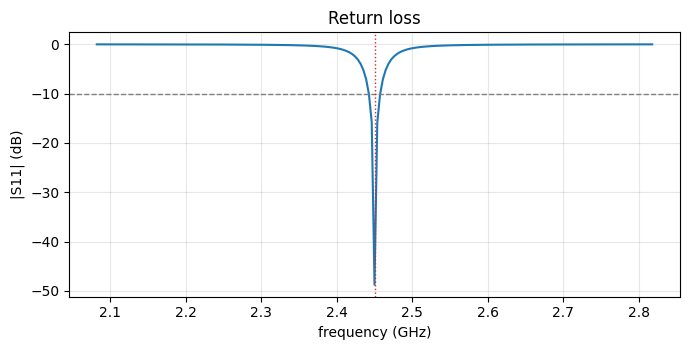

minimum -48.8 dB at 2.4500 GHz


In [8]:
import uuid
import numpy as np
from easyem.solver.registry import get_backend

DEFINITION = {
    "schema_version": "1.0.0",
    "component": {"family": "Antennas", "type": "RectangularPatch"},
    "parameters": {
        "frequency_center": {"value": 2.45, "unit": "GHz", "provenance": "user"},
        "substrate_material": {"value": "RO4003C", "provenance": "user"},
        "substrate_height": {"value": 0.813, "unit": "mm", "provenance": "user"},
    },
}

backend = get_backend("analytical")
ref = backend.submit(DEFINITION, uuid.uuid4())
results = backend.fetch_results(ref)

f = np.array(results.frequencies_hz) / 1e9
s11_db = 20 * np.log10(np.abs(results.s_parameters["S11"]))

plt.figure(figsize=(7, 3.6))
plt.plot(f, s11_db)
plt.axhline(-10, ls="--", c="grey", lw=1)
plt.axvline(2.45, ls=":", c="tab:red", lw=1)
plt.xlabel("frequency (GHz)"); plt.ylabel("|S11| (dB)")
plt.title("Return loss"); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"minimum {s11_db.min():.1f} dB at {f[s11_db.argmin()]:.4f} GHz")

### The radiation pattern

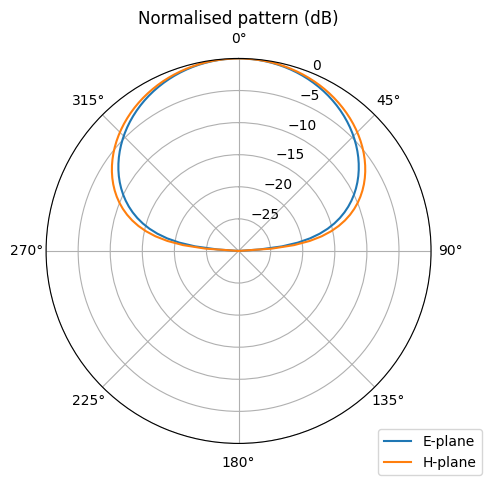

In [9]:
pat = results.radiation_pattern
theta = np.radians(pat["theta_deg"])

fig = plt.figure(figsize=(5.5, 5))
ax = fig.add_subplot(111, projection="polar")
ax.plot(theta, np.maximum(pat["e_plane_db"], -30), label="E-plane")
ax.plot(theta, np.maximum(pat["h_plane_db"], -30), label="H-plane")
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
ax.set_ylim(-30, 0); ax.set_title("Normalised pattern (dB)")
ax.legend(loc="lower right", bbox_to_anchor=(1.15, -0.1))
plt.show()

### Mock output is watermarked

Not a stylistic choice. An RF engineer recognises a non-physical S11 in about
three seconds, and a demo caught doing that does not recover. The flag is set by
the backend so nothing downstream can drop it, and the registry makes `mock`
unreachable by a customer in production.

In [10]:
mock = get_backend("mock")
mock_ref = mock.submit(DEFINITION, uuid.uuid4())
mock.status(mock_ref); mock.status(mock_ref)
mock.status(mock_ref); mock.status(mock_ref)      # it needs a few polls
mock_results = mock.fetch_results(mock_ref)

print("demonstration_only:", mock_results.demonstration_only)
print(mock_results.as_dict()["notice"])

demonstration_only: True
DEMONSTRATION DATA — NOT PHYSICAL. Generated by the mock backend for interface testing. Do not use for design.


---

## 3. The full product

Now the SaaS: accounts, credits, projects, jobs. `nb.signup()` goes through the
real endpoints and reads the verification token out of the outbox — the same
door a user goes through. Reaching into the database to fake verification is how
the fact that no email was ever sent went unnoticed while 203 tests passed.

In [11]:
auth = nb.signup("you@lab.example")
H = auth["headers"]

print("verification email:", nb.outbox.outbox[0].subject)
print("balance:", nb.client.get("/v1/credits/balance", headers=H).json())

INFO easyem request


INFO httpx HTTP Request: POST http://testserver/v1/auth/signup "HTTP/1.1 201 Created"


INFO easyem request


INFO httpx HTTP Request: POST http://testserver/v1/auth/verify-email "HTTP/1.1 200 OK"


INFO easyem request


INFO httpx HTTP Request: POST http://testserver/v1/auth/login "HTTP/1.1 200 OK"


verification email: Confirm your EasyEM address
INFO easyem request


INFO httpx HTTP Request: GET http://testserver/v1/credits/balance "HTTP/1.1 200 OK"


balance: {'account_id': 'f8c13982-a050-4387-8864-027592a668f7', 'balance': '50.000000', 'held': '0', 'available': '50.000000'}


In [12]:
project = nb.client.post("/v1/projects", json={
    "name": "2.45 GHz patch", "component_type": "RectangularPatch",
}, headers=H).json()
pid = project["id"]

version = nb.client.put(f"/v1/projects/{pid}/definition", headers=H,
                        json={"definition": DEFINITION,
                              "change_summary": "Initial design"}).json()

print("status      ", project["status"])
print("valid       ", version["is_valid"])
print("hash        ", version["content_hash"][:26], "...")
for issue in version["validation_report"]["issues"]:
    print(f"  {issue['severity']}: {issue['message'][:70]}")

INFO easyem request


INFO httpx HTTP Request: POST http://testserver/v1/projects "HTTP/1.1 201 Created"


INFO easyem request


INFO httpx HTTP Request: PUT http://testserver/v1/projects/4eddda06-d46b-4a00-8519-7f1859a39d9b/definition "HTTP/1.1 200 OK"


status       draft
valid        True
hash         sha256:a49f04ee2da30d704c2 ...


The hash is taken over the *canonical* form: SI-normalised, key-sorted,
annotations stripped. So 2.45 GHz and 2450 MHz produce the same hash — the same
design, no new version. Changing `provenance` from `user` to `ai_suggested`
doesn't change it either. Changing the frequency does.

In [13]:
from easyem.projects.schema import content_hash
import copy

same_physics = copy.deepcopy(DEFINITION)
same_physics["parameters"]["frequency_center"] = {
    "value": 2450, "unit": "MHz", "provenance": "ai_suggested"}

different = copy.deepcopy(DEFINITION)
different["parameters"]["frequency_center"] = {"value": 5.8, "unit": "GHz"}

print("2450 MHz  == 2.45 GHz :", content_hash(same_physics) == content_hash(DEFINITION))
print("5.8 GHz   == 2.45 GHz :", content_hash(different) == content_hash(DEFINITION))

2450 MHz  == 2.45 GHz : True
5.8 GHz   == 2.45 GHz : False


### Quote, run, settle

The quote is a **ceiling**, not an estimate: it is the number the customer is
shown and the amount held, and they are never charged above it. Submitting
returns immediately — a worker does the work.

In [14]:
quote = nb.client.post(f"/v1/projects/{pid}/simulations/quote",
                       json={}, headers=H).json()
print(f"ceiling {quote['cost_ceiling']}  expected {quote['cost_expected']}  "
      f"balance {quote['available_credits']}")

job = nb.client.post(f"/v1/projects/{pid}/simulations",
                     json={}, headers=H).json()
print(f"submitted: {job['execution_status']} / {job['settlement_status']}")
print("the request did not wait for the solver")

INFO easyem request


INFO httpx HTTP Request: POST http://testserver/v1/projects/4eddda06-d46b-4a00-8519-7f1859a39d9b/simulations/quote "HTTP/1.1 200 OK"


ceiling 1.0  expected 1.0  balance 50.0
INFO easyem request


INFO httpx HTTP Request: POST http://testserver/v1/projects/4eddda06-d46b-4a00-8519-7f1859a39d9b/simulations "HTTP/1.1 201 Created"


submitted: queued / reserved
the request did not wait for the solver


In [15]:
done = nb.work()          # the worker's unit of work, called by hand
print("processed:", len(done))

job = nb.client.get(f"/v1/simulations/{job['id']}", headers=H).json()
print(f"{job['execution_status']} / {job['settlement_status']}  "
      f"charged {job['cost_actual']} of {job['cost_ceiling']}")
print("finished email:", nb.outbox.outbox[-1].subject)

INFO easyem.worker job_claimed


INFO easyem.worker job_finished


processed: 1
INFO easyem request


INFO httpx HTTP Request: GET http://testserver/v1/simulations/c4fc700e-7ef2-4557-820d-acda2eb82dc6 "HTTP/1.1 200 OK"


succeeded / settled  charged 0.1 of 1.0
finished email: Simulation finished: 2.45 GHz patch


### The ledger

Append-only. The balance is a cache, and `reconcile` recomputes it from history.
This is the check to run nightly with an alert on it: a non-empty result means
money is being counted wrong.

In [16]:
for t in reversed(nb.client.get("/v1/credits/transactions", headers=H).json()):
    print(f"  {t['operation']:10} {t['amount']:>12}  -> {t['balance_after']}")

from easyem.credits.service import reconcile
with nb.session() as s:
    print("\nreconcile:", reconcile(s) or "consistent")

INFO easyem request


INFO httpx HTTP Request: GET http://testserver/v1/credits/transactions "HTTP/1.1 200 OK"


  grant         50.000000  -> 50.000000
  reserve       -1.000000  -> 49.000000
  release        1.000000  -> 50.000000
  consume       -0.100000  -> 49.900000

reconcile: consistent


Settlement writes *two* entries rather than one net entry, so a statement shows
what was held and what was actually used.

---

## 4. openEMS

The adapter generates a standalone openEMS script from the Project JSON and runs
it as a subprocess. openEMS is GPL v3, so the boundary is subprocess-and-files —
nothing in `easyem/solver/openems/` imports it, and a test walks the AST of every
module in that package to keep it that way.

The mesh planner works whether or not openEMS is installed, so you can price a
run before deciding to install anything.

In [17]:
from easyem.solver.openems import build, credits_for, openems_available

print("openEMS installed:", openems_available())

run = build(DEFINITION)
plan = run.plan
print(f"\ncells        {plan.cell_count:,}")
print(f"timesteps    {plan.timesteps:,}")
print(f"runtime      ~{plan.estimated_seconds:.0f} s")
print(f"memory       ~{plan.estimated_memory_mb:.0f} MB")
expected, ceiling = credits_for(plan)
print(f"credits      {expected} expected, {ceiling} ceiling")

openEMS installed: False

cells        99,900
timesteps    41,833
runtime      ~167 s
memory       ~160 MB
credits      8.36 expected, 20.9 ceiling


Courant is limited by the *smallest* cell, which is the substrate cell — which
is why thin substrates cost far more timesteps. Missing that understates runtime
and breaches the quoted ceiling.

In [18]:
print(f"{'substrate':>12} {'cells':>10} {'timesteps':>11} {'seconds':>9}")
for h in (0.127, 0.254, 0.508, 0.813, 1.575):
    d = dict(DEFINITION)
    d["parameters"] = dict(DEFINITION["parameters"])
    d["parameters"]["substrate_height"] = {"value": h, "unit": "mm"}
    p = build(d).plan
    print(f"{h:>10.3f}mm {p.cell_count:>10,} {p.timesteps:>11,} "
          f"{p.estimated_seconds:>9.0f}")

   substrate      cells   timesteps   seconds
     0.127mm     93,492     200,000       748
     0.254mm     93,492     200,000       748
     0.508mm     99,900     107,013       428
     0.813mm     99,900      41,833       167
     1.575mm    111,777      11,240        50


In [19]:
# The generated script is plain readable Python. A customer who can read and
# re-run it can verify the result, and checkability is what sells a simulation
# tool to sceptical engineers.
print(run.script[:1400])

"""openEMS run generated by EasyEM. Standalone: read it, edit it, run it.

Requires openEMS (GPL v3) and CSXCAD. EasyEM invokes this file as a separate
process and reads results.json; nothing here is imported into EasyEM.

    python3 run.py <output_directory>
"""

import json
import os
import sys

import numpy as np
from CSXCAD import ContinuousStructure
from openEMS import openEMS
from openEMS.physical_constants import C0, EPS0

OUT = sys.argv[1] if len(sys.argv) > 1 else "."
SIM = os.path.join(OUT, "sim")
UNIT = 1e-3  # all dimensions below are in millimetres

f0 = 2450000000.0
fc = 735000000.0

patch_w = 41.34305502711388
patch_l = 33.097453660949164
sub_w = 46.22105502711388
sub_l = 37.975453660949164
sub_h = 0.813
eps_r = 3.38
tan_d = 0.0027
feed_y = -4.548726830474581
feed_R = 50.0

res = 2.5598995290470143
edge_res = 1.2799497645235072
sub_cells = 4

# Dielectric loss enters openEMS as a conductivity at the design frequency.
kappa = tan_d * 2 * np.pi * f0 * EPS0 * eps_r

FDTD =

---

## 5. Where to go next

- `easyem/engineering/components.py` — add a component: a schema entry with
  bounds, plus an analytical model. That is the product's IP, and it currently
  holds two components.
- `tests/solver_contract/` — the acceptance test for a new backend. EMG-TLM is
  integrated the day it goes green there. See
  `docs/adding-a-solver-backend.md`.
- `easyem/credits/service.py` — the ledger, if you want to change the pricing
  model.

Two things this notebook cannot tell you, and that matter more than any of the
above: nobody has compared these models to a **measurement** (etch one patch,
put it on a VNA — a week of work, and your best commercial argument), and nobody
has asked five RF engineers how they buy tools.